--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB
None

--- Target Distribution ---
y
no     39922
yes     5289
Name: count, dtype: int64


c:\Users\SBT\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Logistic Regression Evaluation ---
F1-Score: 0.4523
ROC AUC: 0.9004
Confusion Matrix:
[[7746  206]
 [ 712  379]]

--- Random Forest Evaluation ---
F1-Score: 0.3012
ROC AUC: 0.9185
Confusion Matrix:
[[7881   71]
 [ 885  206]]


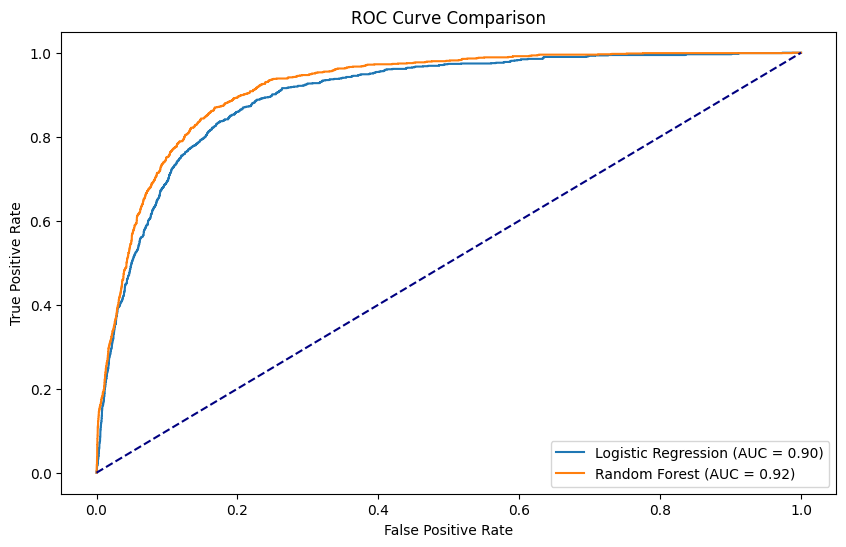

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, f1_score, roc_auc_score, 
                             roc_curve, classification_report)

# 1. Load and Explore the Dataset
# The file uses standard comma delimiters
df = pd.read_csv(r'D:\\UNI BSCS\\4 sem\\AI LAB\\LAB 1\\archive\\bank-full.csv')

print("--- Dataset Info ---")
print(df.info())
print("\n--- Target Distribution ---")
print(df['y'].value_counts())

# 2. Preprocessing & Encoding
# Map target 'y' to binary integers
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Encode categorical features using One-Hot Encoding
X = pd.get_dummies(df.drop('y', axis=1), drop_first=True)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training
# a) Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# b) Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Evaluation
models = {'Logistic Regression': lr_model, 'Random Forest': rf_model}

plt.figure(figsize=(10, 6))

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n--- {name} Evaluation ---")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    # ROC Curve Data
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# 5. Explain Model Predictions with SHAP (Random Forest)
# Initialize TreeExplainer for the Random Forest model
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Handling SHAP versioning: Select Class 1 (Yes)
if isinstance(shap_values, list):
    # Older versions return a list of arrays
    final_shap_values = shap_values
    expected_val = explainer.expected_value
else:
    # Newer versions may return a 3D array [samples, features, classes]
    final_shap_values = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values
    expected_val = explainer.expected_value if hasattr(explainer.expected_value, "__len__") else explainer.expected_value

# a) Global Summary Plot
print("\nGenerating SHAP Summary Plot...")
shap.summary_plot(final_shap_values, X_test)

# b) Individual Explanations for 5 specific predictions
print("\nExplaining 5 Individual Predictions...")
for i in range(5):
    print(f"Customer {i+1} Prediction Explanation:")
    # We use matplotlib=True to render inside the script environment
    shap.force_plot(
        expected_val, 
        final_shap_values[i, :], 
        X_test.iloc[i, :], 
        matplotlib=True
    )